In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs umap-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 151.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 67.6 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=058cf209888e1d3472d790695a4e1e3da06f8efed9b6e926d55829389713b4c8
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [3]:
import os
import shutil
import datetime
import gc
import numpy as np
import tensorflow as tf
import random
from typing import Literal
import matplotlib.pyplot as plt
import pandas as pd
import math
from dataclasses import dataclass
from collections.abc import Iterable
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [4]:
ModelType = Literal["pair", "triplet"]

@dataclass
class ModelConfig:
    type: ModelType

@dataclass
class DataConfig:
    authors_range: Iterable[int]
    original_shape: tuple[int, int, int]
    model_input_shape: tuple[int, int, int]

    def __post_init__(self):
        authors_array = np.asarray(list(self.authors_range))

        if authors_array.ndim != 1 or len(authors_array) == 0:
            raise ValueError("authors_range must be a non-empty 1D iterable")

        if len(np.unique(authors_array)) != len(authors_array):
            raise ValueError("authors_range contains duplicates")

        self.authors_range = authors_array
        self.authors = len(authors_array)


@dataclass
class TrainingConfig:
    epochs: int
    seed: int
    val_ratio: float

    def __post_init__(self):
        assert 0 < self.val_ratio < 1, "val_ratio must be between 0 and 1"


@dataclass
class BatchConfig:
    train: int
    validation: int
    test: int

    def __post_init__(self):
        assert self.train > 0
        assert self.validation > 0
        assert self.test > 0


@dataclass
class Config:
    project_path: str
    dataset: str
    model: ModelConfig
    data: DataConfig
    training: TrainingConfig
    batch: BatchConfig
    current_time: str

In [26]:
config = Config(
    project_path='drive/MyDrive/author-handwriting-recog',
    dataset='dataset_4_ImagesLinesRemoved_20260310-153450',
    model=ModelConfig(type="triplet"),
    data=DataConfig(
        authors_range=range(0, 204),
        original_shape=(180, 360, 1),
        model_input_shape=(120, 240, 3),
    ),
    training=TrainingConfig(
        epochs=50,
        seed=42,
        val_ratio=0.25
    ),
    batch=BatchConfig(
        train=64,
        validation=32,
        test=16,
    ),
    current_time=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

In [6]:
def upload_source(source: str, source_dest: str):
    if os.path.exists(source_dest):
        shutil.rmtree(source_dest)

    shutil.copytree(source, source_dest)

In [7]:
src_drive = f"{config.project_path}/src"
src_local = "./src"

In [8]:
src_data_drive = f"{config.project_path}/data/datasets/180_360_90"
src_data_local = f"./dataset"

In [9]:
upload_source(source=src_drive, source_dest=src_local)

In [10]:
upload_source(source=src_data_drive, source_dest=src_data_local)

In [11]:
random.seed(config.training.seed)
np.random.seed(config.training.seed)
tf.random.set_seed(config.training.seed)

In [12]:
from src.io import LoggerFactory
from src.datasets.loaders import SelectiveDataLoader
from src.generators import (
    AugmentationPipeline,
    AugmentationOps,
    AugmentImage,
    BaseGenerator,
    DataGenerator,
    TripletGenerator,
)

In [13]:
from src.models import MobileNetV2Backbone, TripletLoss
from src.training import (
    get_default_callbacks,
    ModelTrainerFactory,
)
from src.evaluator import (
    TripletEvaluator,
)

In [ ]:
from src.evaluator.embedding_utils import EmbeddingExtractor
from src.evaluator.embedding_strategy import (
    StrategyPipeline,
    OneNNStrategy,
    MeanStrategy,
    CentroidStrategy,
    TopKStrategy,
    PatchAggregator,
    VoteAggregator,
    ScoreAggregator,
)
from src.evaluator import EmbeddingEvaluator, EmbeddingVisualizer

In [14]:
logger = LoggerFactory.get_logger(
    "mobile_test_204_4",
    log_dir=f"./logs_{config.current_time}",
    file_prefix=f"mobile_triplet_{config.current_time}"
)

In [15]:
dataset_path = f"dataset/{config.dataset}.tar.gz"

In [16]:
!tar -xzf {dataset_path} -C ./

In [17]:
loader = SelectiveDataLoader(
    dataset_path=f"./{config.dataset}.zarr",
    logger=logger,
    seed=config.training.seed
)

In [19]:
train, val, test = loader.build(
      authors=config.data.authors_range,
      validation_fraction=config.training.val_ratio,
  )

04:23:09 - mobile_test_204_4 - INFO - Total patches selected: 128891
04:23:09 - mobile_test_204_4 - INFO - Train: 96668 | Val: 32223 | Test: 8946
04:23:09 - mobile_test_204_4 - INFO - Avg non_test patches per author: 631.82 | Min: 142 | Max: 911
04:23:09 - mobile_test_204_4 - INFO - Avg test patches per author: 43.85 | Min: 22 | Max: 49
04:23:09 - mobile_test_204_4 - INFO - Image shape: (180, 360)
04:23:09 - mobile_test_204_4 - INFO - Zarr chunk shape: (64, 180, 360)


In [20]:
ops = AugmentationOps(
    rotation_range=6,
    width_shift_range=0.04,
    height_shift_range=0.05,
    horizontal_flip=False,
    resize_dim=config.data.model_input_shape[:2],
    brightness_delta=0.04,
    contrast_range=(0.95, 1.05),
    noise_stddev=0.01,
    zoom_range=(0.95, 1.05),
)
pipeline_train = AugmentationPipeline([
    ops.rotate,
    ops.zoom,
    ops.shift,
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
pipeline = AugmentationPipeline([
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
augment_train = AugmentImage(pipeline_train)
augment = AugmentImage(pipeline)

In [27]:
train_triplet = TripletGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_triplet = TripletGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_triplet = TripletGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [28]:
def display_generator_info(generator: BaseGenerator):
    config = generator.get_config()
    logger.info(f"Generator: {generator.__class__.__name__}")
    logger.info(f"Number of samples: {config['num_samples']}")
    logger.info(f"Batch size: {config['batch_size']}")
    logger.info(f"Steps per epoch: {config['steps_per_epoch']}")
    logger.info(f"Shape: {config['patch_shape']}")
    logger.info(f"Number of authors: {config['num_authors']}")

In [29]:
display_generator_info(train_triplet)

04:23:55 - mobile_test_204_4 - INFO - Generator: TripletGenerator
04:23:55 - mobile_test_204_4 - INFO - Number of samples: 96668
04:23:55 - mobile_test_204_4 - INFO - Batch size: 64
04:23:55 - mobile_test_204_4 - INFO - Steps per epoch: 1511
04:23:55 - mobile_test_204_4 - INFO - Shape: (180, 360)
04:23:55 - mobile_test_204_4 - INFO - Number of authors: 204


In [30]:
display_generator_info(val_triplet)

04:23:57 - mobile_test_204_4 - INFO - Generator: TripletGenerator
04:23:57 - mobile_test_204_4 - INFO - Number of samples: 32223
04:23:57 - mobile_test_204_4 - INFO - Batch size: 32
04:23:57 - mobile_test_204_4 - INFO - Steps per epoch: 1007
04:23:57 - mobile_test_204_4 - INFO - Shape: (180, 360)
04:23:57 - mobile_test_204_4 - INFO - Number of authors: 204


In [31]:
display_generator_info(test_triplet)

04:23:57 - mobile_test_204_4 - INFO - Generator: TripletGenerator
04:23:57 - mobile_test_204_4 - INFO - Number of samples: 8946
04:23:57 - mobile_test_204_4 - INFO - Batch size: 16
04:23:57 - mobile_test_204_4 - INFO - Steps per epoch: 560
04:23:57 - mobile_test_204_4 - INFO - Shape: (180, 360)
04:23:57 - mobile_test_204_4 - INFO - Number of authors: 204


In [32]:
trainer = ModelTrainerFactory.create(
    backbone=MobileNetV2Backbone(freeze_base=False, fine_tune_at=100),
    input_shape=config.data.model_input_shape,
    num_authors=config.data.authors,
    train_generator=train_triplet,
    val_generator=val_triplet,
    model_name="mobilenet_triplet",
    model_type=config.model.type,
)

04:24:05 - mobile_test_204_4 - INFO - [EmbeddingConfig] author=204 | embedding_dim=224 | projection_dim=448


In [33]:
trainer.initialize_model()

/content/src/models/backbones/mobile_net.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


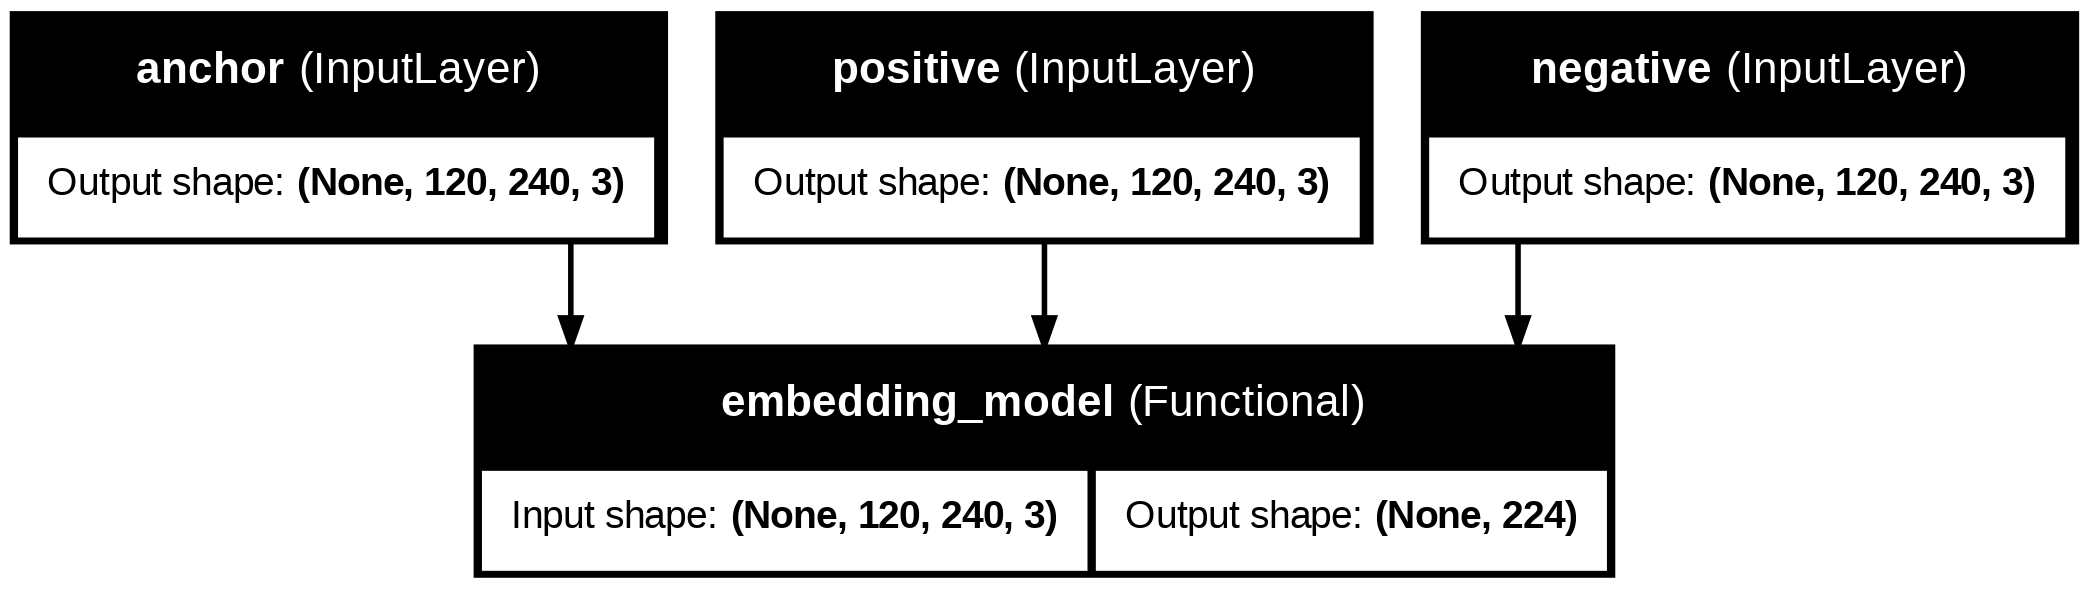

In [34]:
tf.keras.utils.plot_model(
    trainer.siamese_network,
    show_shapes=True,
    show_layer_names=True,
)

In [35]:
trainer.siamese_network.summary()

Model: "siamese_triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 120, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 224)       │  2,935,136 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,935,136 (11.20 MB)

 Trainable params: 2,537,248 (9.68 MB)

 Non-trainable params: 397,888 (1.52 MB)

In [36]:
trainer.embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_dense_1 (Dense)      │ (None, 448)            │       573,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 448)            │         1,792 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 224)            │       100,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224)            │           896 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 224)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,935,136 (11.20 MB)

 Trainable params: 2,537,248 (9.68 MB)

 Non-trainable params: 397,888 (1.52 MB)

In [41]:
trainer.compile(
    loss=TripletLoss(margin=0.4),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=[
        tf.keras.metrics.Mean(name="ap_sim"),
        tf.keras.metrics.Mean(name="an_sim"),
        tf.keras.metrics.Mean(name="margin"),
        tf.keras.metrics.Mean(name="triplet_acc"),
    ],
)

In [42]:
callbacks = get_default_callbacks(
    model_name="mobile_siamese_triplet",
    monitor="val_loss",
    mode="min",
    patience=4,
    start_from_epoch=5,
    reduce_lr_patience=2,
)

In [43]:
history = trainer.train_model(
    epochs=config.training.epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - an_sim: 4.2693e-04 - ap_sim: 0.0808 - loss: 0.3330 - margin: 0.0803 - triplet_acc: 0.6349
Epoch 1: val_loss improved from None to 0.23738, saving model to checkpoints/mobile_siamese_triplet/best.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)



Epoch 1: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 660s 381ms/step - an_sim: 3.6796e-04 - ap_sim: 0.1525 - loss: 0.2896 - margin: 0.1521 - triplet_acc: 0.6882 - val_an_sim: 0.0785 - val_ap_sim: 0.3153 - val_loss: 0.2374 - val_margin: 0.2368 - val_triplet_acc: 0.7512 - learning_rate: 1.0000e-05
Epoch 2/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - an_sim: 0.0012 - ap_sim: 0.3052 - loss: 0.2189 - margin: 0.3040 - triplet_acc: 0.7670
Epoch 2: val_loss improved from 0.23738 to 0.19522, saving model to checkpoints/mobile_siamese_triplet/best.keras

Epoch 2: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 484s 318ms/step - an_sim: 9.4050e-04 - ap_sim: 0.3303 - loss: 0.2091 - margin: 0.3294 - triplet_acc: 0.7779 - val_an_sim: 0.0724 - val_ap_sim: 0.4019 - val_loss: 0.1952 - val_margin: 0.3295 - val_triplet_acc: 0.8004 - learning_rate: 1.0000e-05
Epoch 3/50
1510/1511 ━━━━━━━━━

KeyboardInterrupt: 

In [ ]:
def plot_keras_history(history: tf.keras.callbacks.History):

    df = pd.DataFrame(history.history)

    metrics = [col for col in df.columns if not col.startswith("val_")]

    n_metrics = len(metrics)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        ax.plot(df[metric], label=f"train_{metric}")

        val_metric = f"val_{metric}"
        if val_metric in df.columns:
            ax.plot(df[val_metric], label=f"val_{metric}")

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

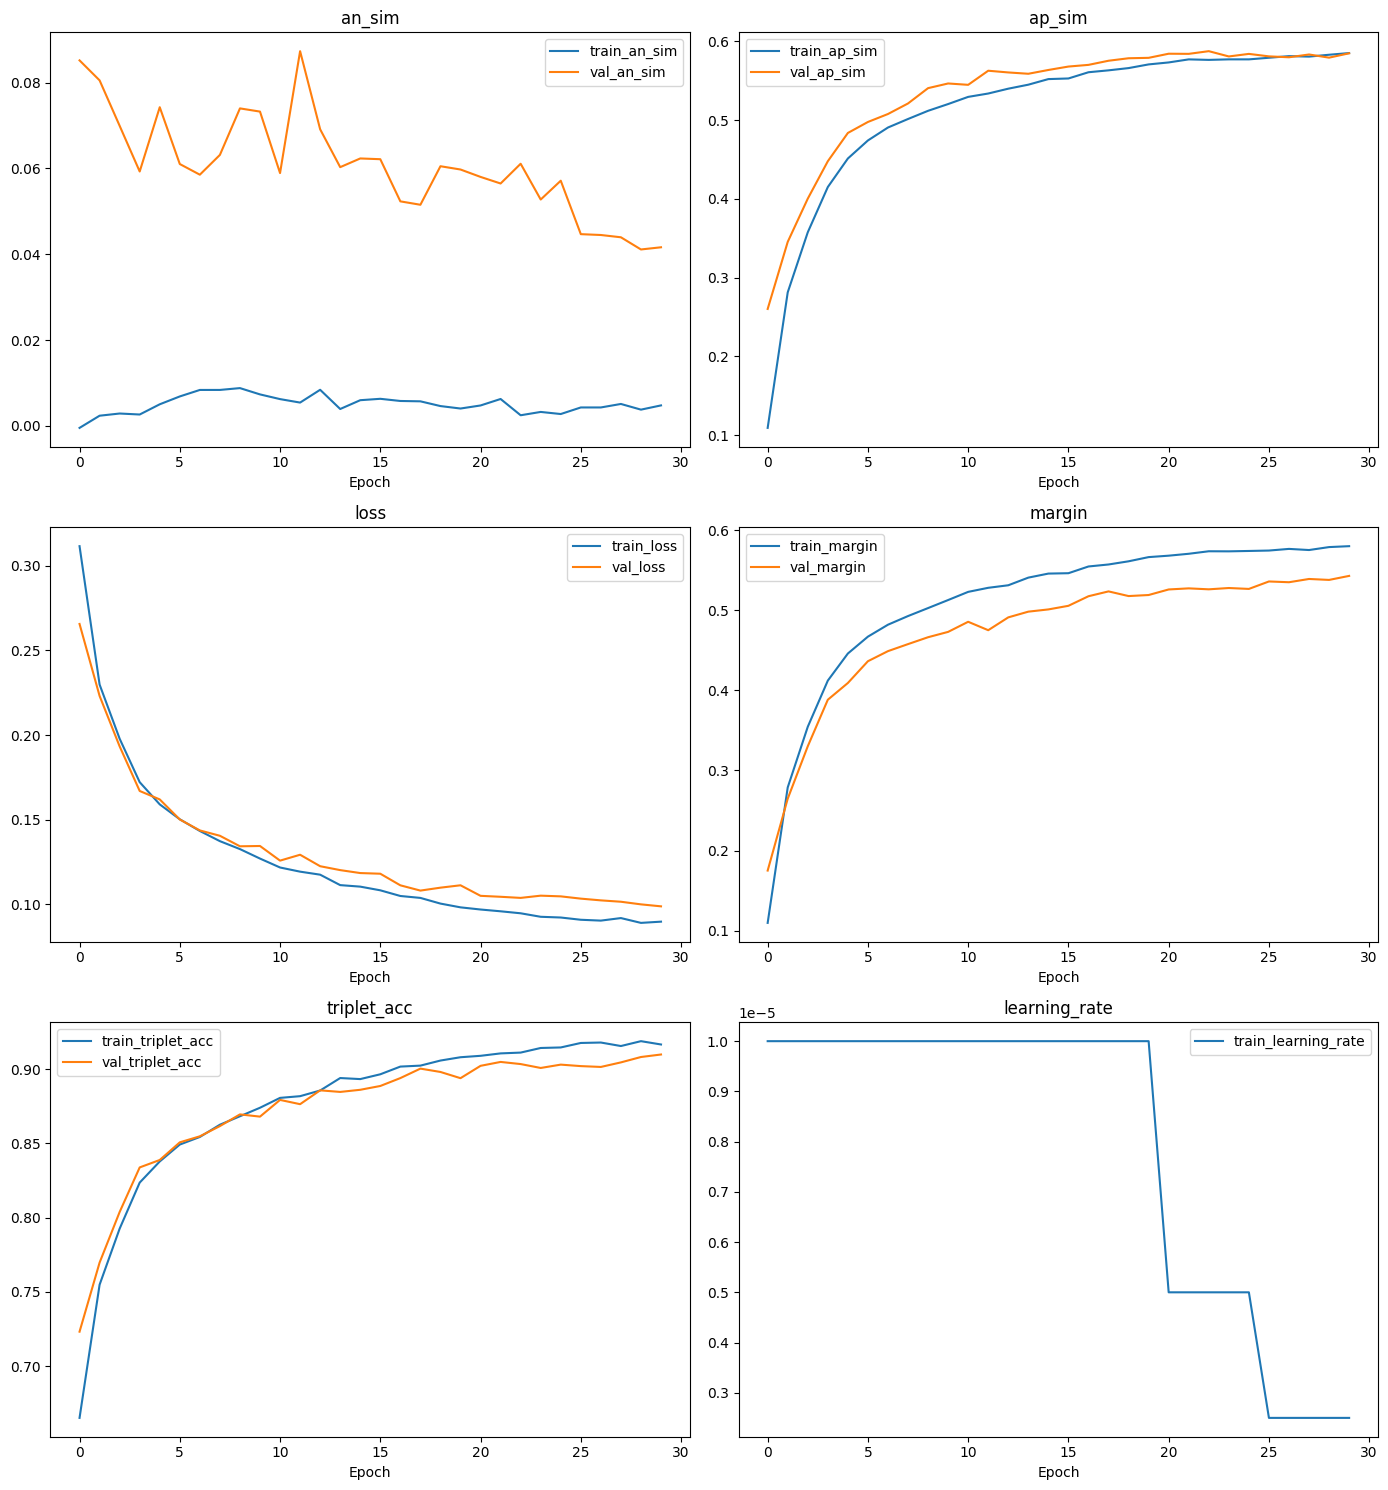

In [ ]:
plot_keras_history(history)

In [44]:
os.makedirs("./models", exist_ok=True)
trainer.siamese_network.save(f"./models/mobilenet_siamese_model_204_{config.current_time}.keras")
trainer.embedding_model.save(f"./models/mobilenet_embedding_model_204_{config.current_time}.keras")

In [ ]:
trainer.siamese_network.load_weights("./models/mobilenet_siamese_model_204_20260323-191301.keras")

In [45]:
metrics_val = trainer.evaluate_dict(val_triplet)
logger.info(f"{metrics_val}")

1007/1007 ━━━━━━━━━━━━━━━━━━━━ 92s 90ms/step - an_sim: 0.0384 - ap_sim: 0.5836 - loss: 0.1048 - margin: 0.5451 - triplet_acc: 0.9003


{'an_sim': 0.038442064076662064,
 'ap_sim': 0.5835778713226318,
 'loss': 0.10484933853149414,
 'margin': 0.5451358556747437,
 'triplet_acc': 0.9003196358680725}

In [46]:
metrics_test = trainer.evaluate_dict(test_triplet)
logger.info(f"{metrics_test}")

560/560 ━━━━━━━━━━━━━━━━━━━━ 61s 74ms/step - an_sim: 0.0287 - ap_sim: 0.6371 - loss: 0.0837 - margin: 0.6085 - triplet_acc: 0.9262
07:26:07 - mobile_test_204_4 - INFO - {'an_sim': 0.028663160279393196, 'ap_sim': 0.6371443271636963, 'loss': 0.08373243361711502, 'margin': 0.6084816455841064, 'triplet_acc': 0.9262239933013916}


In [47]:
def build_author_confusion_matrix(
    df: pd.DataFrame,
    true_col: str = "author_i",
    pred_col: str = "author_j"
) -> pd.DataFrame:
    authors = sorted(df[true_col].unique())

    cm = confusion_matrix(
        df[true_col],
        df[pred_col],
        labels=authors
    )

    cm_df = pd.DataFrame(
        cm,
        index=authors,
        columns=authors
    )

    return cm_df

In [48]:
def display_heatmap(df: pd.DataFrame) -> None:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df, cmap="Blues", linewidths=0.5)

    plt.xlabel("Predicted Author")
    plt.ylabel("True Author")
    plt.title("Confusion Matrix")
    plt.show()

In [49]:
triplet_evaluator = TripletEvaluator(
    model=trainer,
    logger=logger,
)

In [50]:
triplet_evaluator.data_generator = test_triplet
triplet_report = triplet_evaluator.evaluate()

07:26:07 - mobile_test_204_4 - INFO - === Triplet Evaluation Started ===
07:26:08 - mobile_test_204_4 - INFO - === Collecting triplet results ===
07:26:44 - mobile_test_204_4 - INFO - Total triplets collected: 560
07:26:44 - mobile_test_204_4 - INFO - [LOCAL] acc=0.9307 gap=0.6189 error=0.0693 auc=0.9320
07:26:44 - mobile_test_204_4 - INFO - === Computing global metrics ===
07:26:44 - mobile_test_204_4 - INFO - === Global metrics computed ===
07:26:44 - mobile_test_204_4 - INFO - === Triplet Evaluation Finished ===


In [51]:
triplet_report.local_metrics.auc, triplet_report.local_metrics.triplet_accuracy

(0.9319799363535962, 0.9306952828079589)

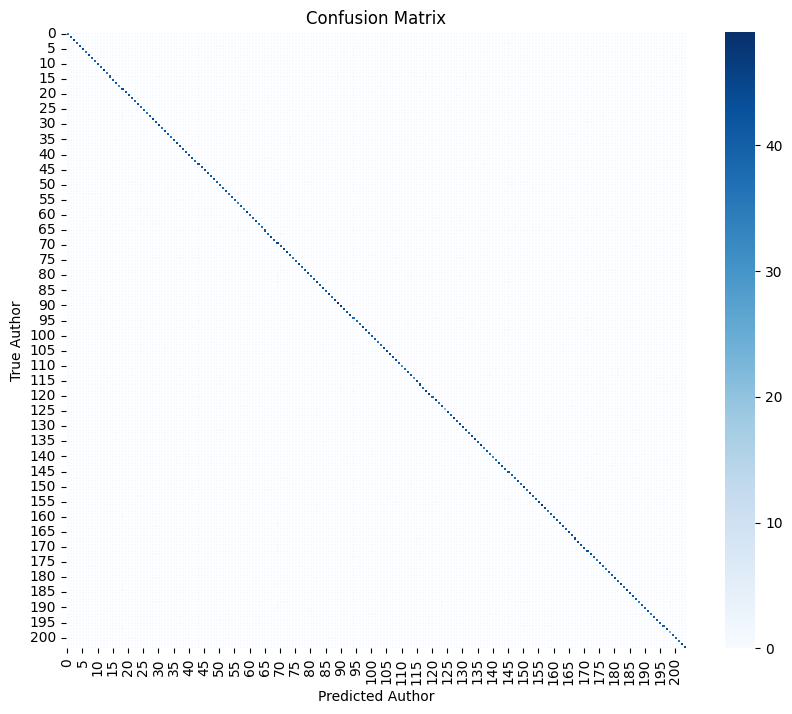

In [52]:
cm_df = build_author_confusion_matrix(
    triplet_report.df_triplets,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df)

In [53]:
triplet_report.global_metrics.df_by_score

,anchor_label,pred_label,accuracy,mean_gap,count,gap_norm,score
0,0,0,1.0,1.013707,36,0.994118,0.994118
1,1,1,1.0,0.742790,41,0.861955,0.861955
2,2,2,1.0,0.968259,47,0.971947,0.971947
3,3,3,1.0,0.452661,39,0.720419,0.720419
4,4,4,1.0,0.594969,42,0.789842,0.789842
...,...,...,...,...,...,...,...
199,199,199,1.0,0.676428,41,0.829581,0.829581
200,200,200,1.0,0.517873,39,0.752232,0.752232
201,201,201,1.0,0.561194,36,0.773365,0.773365
202,202,202,1.0,0.867973,45,0.923024,0.923024


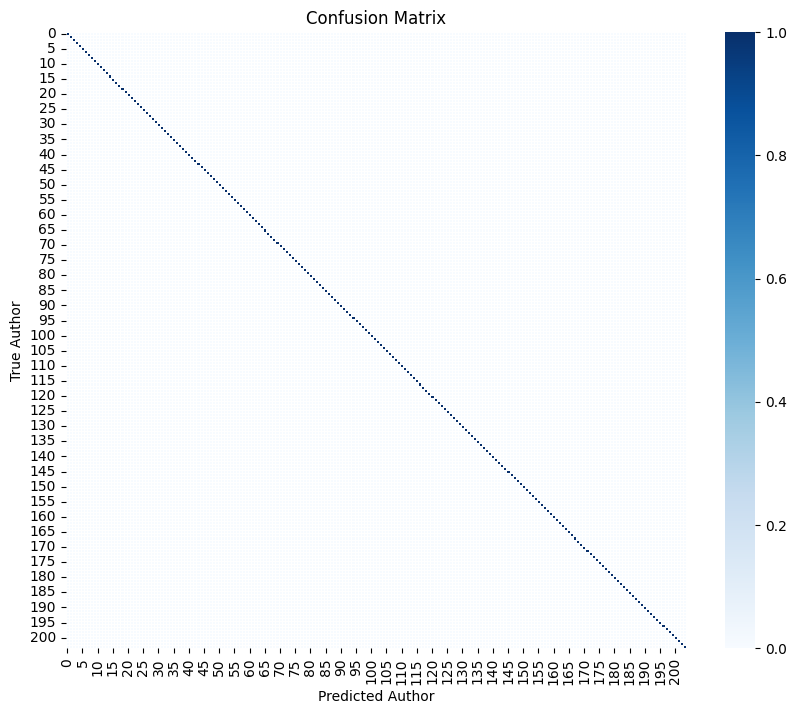

In [54]:
cm_df = build_author_confusion_matrix(
    triplet_report.global_metrics.df_by_score,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df)

In [55]:
train_gen = DataGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_gen = DataGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_gen = DataGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [56]:
display_generator_info(train_gen)

07:28:51 - mobile_test_204_4 - INFO - Generator: DataGenerator
07:28:51 - mobile_test_204_4 - INFO - Number of samples: 96668
07:28:51 - mobile_test_204_4 - INFO - Batch size: 64
07:28:51 - mobile_test_204_4 - INFO - Steps per epoch: 1511
07:28:51 - mobile_test_204_4 - INFO - Shape: (180, 360)
07:28:51 - mobile_test_204_4 - INFO - Number of authors: 204


In [57]:
display_generator_info(val_gen)

07:28:53 - mobile_test_204_4 - INFO - Generator: DataGenerator
07:28:53 - mobile_test_204_4 - INFO - Number of samples: 32223
07:28:53 - mobile_test_204_4 - INFO - Batch size: 32
07:28:53 - mobile_test_204_4 - INFO - Steps per epoch: 1007
07:28:53 - mobile_test_204_4 - INFO - Shape: (180, 360)
07:28:53 - mobile_test_204_4 - INFO - Number of authors: 204


In [58]:
display_generator_info(test_gen)

07:28:54 - mobile_test_204_4 - INFO - Generator: DataGenerator
07:28:54 - mobile_test_204_4 - INFO - Number of samples: 8946
07:28:54 - mobile_test_204_4 - INFO - Batch size: 16
07:28:54 - mobile_test_204_4 - INFO - Steps per epoch: 560
07:28:54 - mobile_test_204_4 - INFO - Shape: (180, 360)
07:28:54 - mobile_test_204_4 - INFO - Number of authors: 204


In [59]:
extractor = EmbeddingExtractor(
    model=trainer.embedding_model,
    logger=logger,
)

In [ ]:
strategy_pipeline = StrategyPipeline(
    strategies=[
        OneNNStrategy(), MeanStrategy(), CentroidStrategy(), TopKStrategy(k=5),
    ],
    aggregators=[PatchAggregator(), VoteAggregator(), ScoreAggregator()],
    logger=logger,
)

In [60]:
emb_evaluator = EmbeddingEvaluator(
    extractor=extractor,
    pipeline=strategy_pipeline,
    logger=logger,
    seed=config.training.seed
)

In [62]:
val_gen_results = emb_evaluator.evaluate(val_gen)

07:29:36 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Starting evaluation
07:29:36 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Preparing embeddings for distance computation
07:29:36 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(32223, 224)
07:29:36 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Building author pair similarities
07:29:48 - mobile_test_204_4 - INFO - [Pairs] Built in 11.51s
07:29:48 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


07:30:32 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] UMAP completed in 44.92s
07:30:32 - mobile_test_204_4 - INFO - [UMAP] Completed in 44.96s
07:30:33 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
07:30:33 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] intra=0.3619 | inter=0.9565 | ratio=0.3783 | time=0.01s
07:30:33 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Evaluating strategies: ['1nn', 'mean', 'centroid', 'topk']
07:30:33 - mobile_test_204_4 - INFO - [Pipeline] Applying strategy: 1nn
07:30:33 - mobile_test_204_4 - INFO - [Strategy:1NN] Computing similarity matrix
07:30:38 - mobile_test_204_4 - INFO - [Strategy:1NN] Accuracy=0.3275
07:30:38 - mobile_test_204_4 - INFO - [Strategy: 1nn] patch_acc=0.3275 | vote_acc=0.9902 | score_acc=0.0343 | time=5.79s
07:30:38 - mobile_test_204_4 - INFO - [Pipeline] Applying strategy: mean
07:30:38 - mobile_test_204_4 - INFO - [Strategy:Mean] Computing author mean similarity
07:35:05 - mobile_test_2

In [63]:
logger.info(f"Intra distance: {val_gen_results.intra_distance}")
logger.info(f"Inter distance: {val_gen_results.inter_distance}")

for strategy_name, agg_results in val_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

07:42:12 - mobile_test_204_4 - INFO - Intra distance: 0.36185121536254883
07:42:12 - mobile_test_204_4 - INFO - Inter distance: 0.956524133682251
07:42:12 - mobile_test_204_4 - INFO - Strategy: 1nn
07:42:12 - mobile_test_204_4 - INFO - Patch accuracy: 0.3275
07:42:12 - mobile_test_204_4 - INFO - Vote accuracy:  0.9902
07:42:12 - mobile_test_204_4 - INFO - Score accuracy: 0.0343
07:42:12 - mobile_test_204_4 - INFO - ----------------------------------------
07:42:12 - mobile_test_204_4 - INFO - Strategy: mean
07:42:12 - mobile_test_204_4 - INFO - Patch accuracy: 0.2606
07:42:12 - mobile_test_204_4 - INFO - Vote accuracy:  0.5637
07:42:12 - mobile_test_204_4 - INFO - Score accuracy: 0.0490
07:42:12 - mobile_test_204_4 - INFO - ----------------------------------------
07:42:12 - mobile_test_204_4 - INFO - Strategy: centroid
07:42:12 - mobile_test_204_4 - INFO - Patch accuracy: 0.3102
07:42:12 - mobile_test_204_4 - INFO - Vote accuracy:  0.9265
07:42:12 - mobile_test_204_4 - INFO - Score ac

In [65]:
test_gen_results = emb_evaluator.evaluate(test_gen)

07:42:22 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Starting evaluation
07:42:22 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Preparing embeddings for distance computation
07:42:22 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(8946, 224)
07:42:22 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Building author pair similarities
07:42:25 - mobile_test_204_4 - INFO - [Pairs] Built in 3.48s
07:42:25 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


07:42:40 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] UMAP completed in 15.12s
07:42:40 - mobile_test_204_4 - INFO - [UMAP] Completed in 15.13s
07:42:40 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
07:42:40 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] intra=0.3542 | inter=0.9737 | ratio=0.3637 | time=0.01s
07:42:40 - mobile_test_204_4 - INFO - [EmbeddingEvaluator] Evaluating strategies: ['1nn', 'mean', 'centroid', 'topk']
07:42:40 - mobile_test_204_4 - INFO - [Pipeline] Applying strategy: 1nn
07:42:40 - mobile_test_204_4 - INFO - [Strategy:1NN] Computing similarity matrix
07:42:41 - mobile_test_204_4 - INFO - [Strategy:1NN] Accuracy=0.6560
07:42:41 - mobile_test_204_4 - INFO - [Strategy: 1nn] patch_acc=0.6560 | vote_acc=1.0000 | score_acc=0.2500 | time=0.35s
07:42:41 - mobile_test_204_4 - INFO - [Pipeline] Applying strategy: mean
07:42:41 - mobile_test_204_4 - INFO - [Strategy:Mean] Computing author mean similarity
07:43:12 - mobile_test_2

In [66]:
logger.info(f"Intra distance: {test_gen_results.intra_distance}")
logger.info(f"Inter distance: {test_gen_results.inter_distance}")

for strategy_name, agg_results in test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

07:44:08 - mobile_test_204_4 - INFO - Intra distance: 0.3541550636291504
07:44:08 - mobile_test_204_4 - INFO - Inter distance: 0.9737295508384705
07:44:08 - mobile_test_204_4 - INFO - Strategy: 1nn
07:44:08 - mobile_test_204_4 - INFO - Patch accuracy: 0.6560
07:44:08 - mobile_test_204_4 - INFO - Vote accuracy:  1.0000
07:44:08 - mobile_test_204_4 - INFO - Score accuracy: 0.2500
07:44:08 - mobile_test_204_4 - INFO - ----------------------------------------
07:44:08 - mobile_test_204_4 - INFO - Strategy: mean
07:44:08 - mobile_test_204_4 - INFO - Patch accuracy: 0.3526
07:44:08 - mobile_test_204_4 - INFO - Vote accuracy:  0.5784
07:44:08 - mobile_test_204_4 - INFO - Score accuracy: 0.1275
07:44:08 - mobile_test_204_4 - INFO - ----------------------------------------
07:44:08 - mobile_test_204_4 - INFO - Strategy: centroid
07:44:08 - mobile_test_204_4 - INFO - Patch accuracy: 0.4215
07:44:08 - mobile_test_204_4 - INFO - Vote accuracy:  0.9020
07:44:08 - mobile_test_204_4 - INFO - Score ac

In [67]:
viz = EmbeddingVisualizer(
    report=test_gen_results,
    logger=logger,
    loader=test.loader,
)

In [ ]:
viz.set_strategy("1nn")

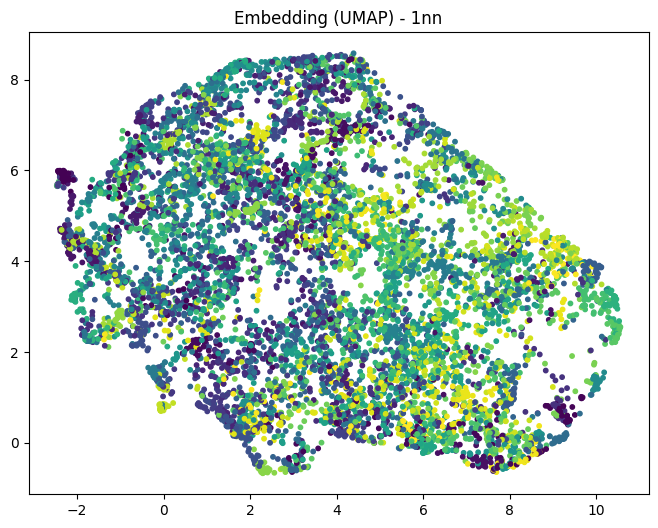

In [68]:
viz.plot_embeddings_2d()

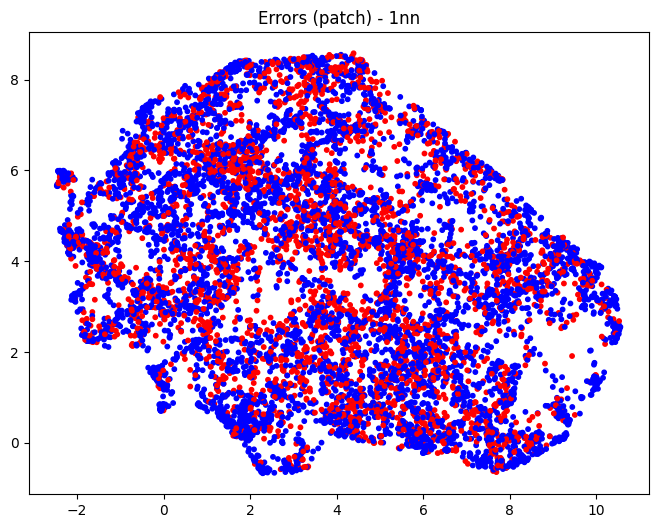

In [69]:
viz.plot_errors_2d(level="patch")

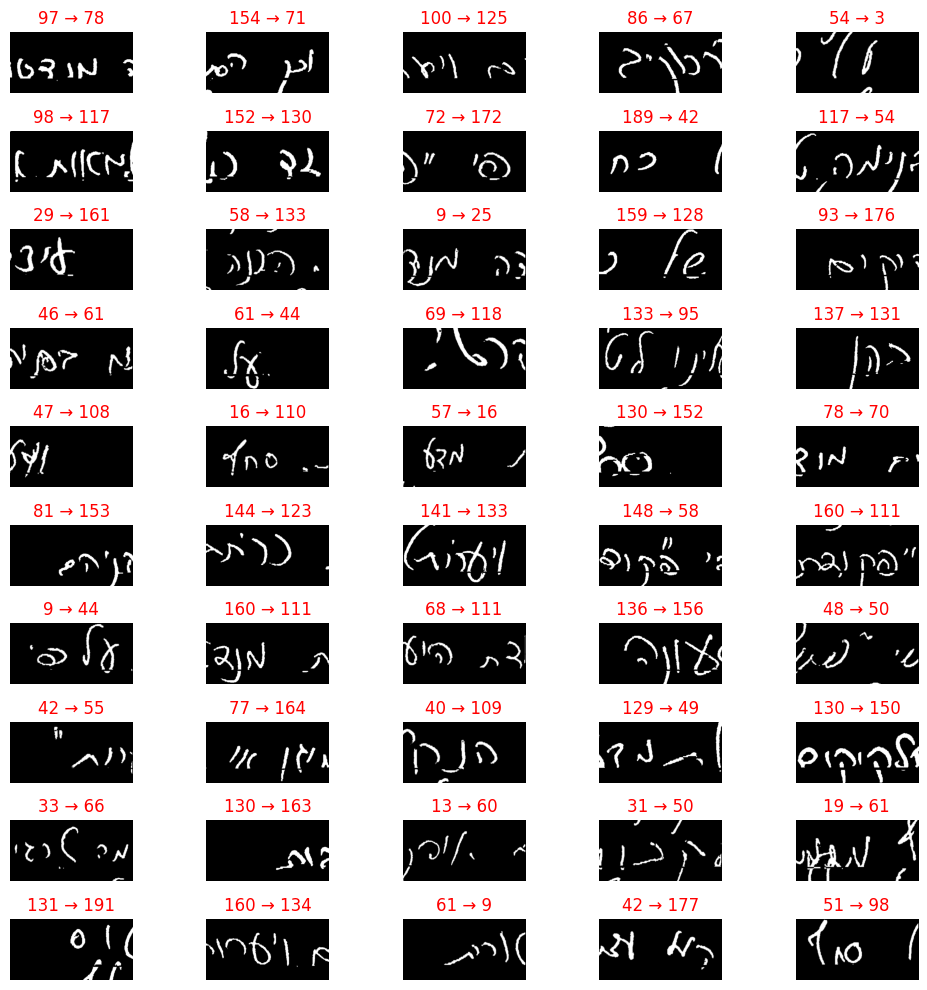

In [70]:
viz.plot_error_images()

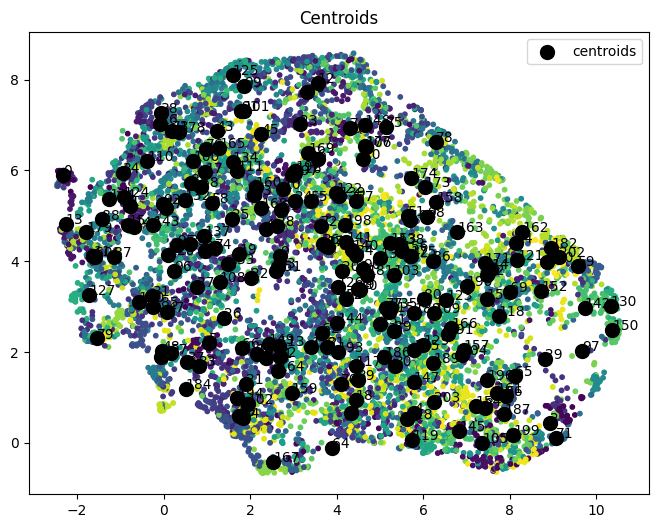

In [71]:
viz.plot_centroids()

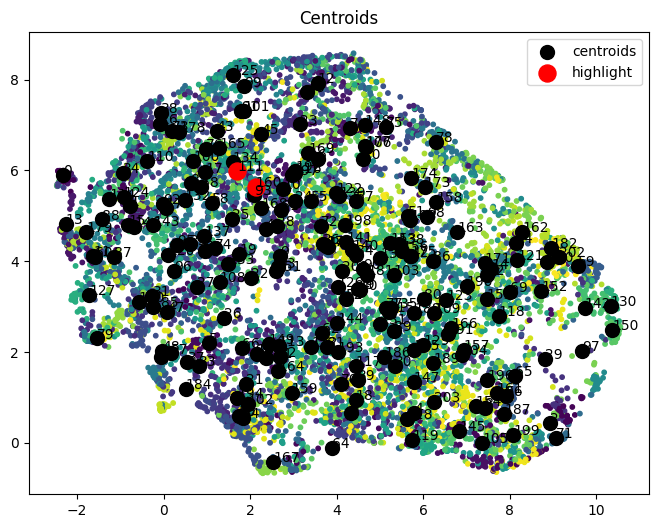

In [72]:
viz.plot_centroids([160, 111])

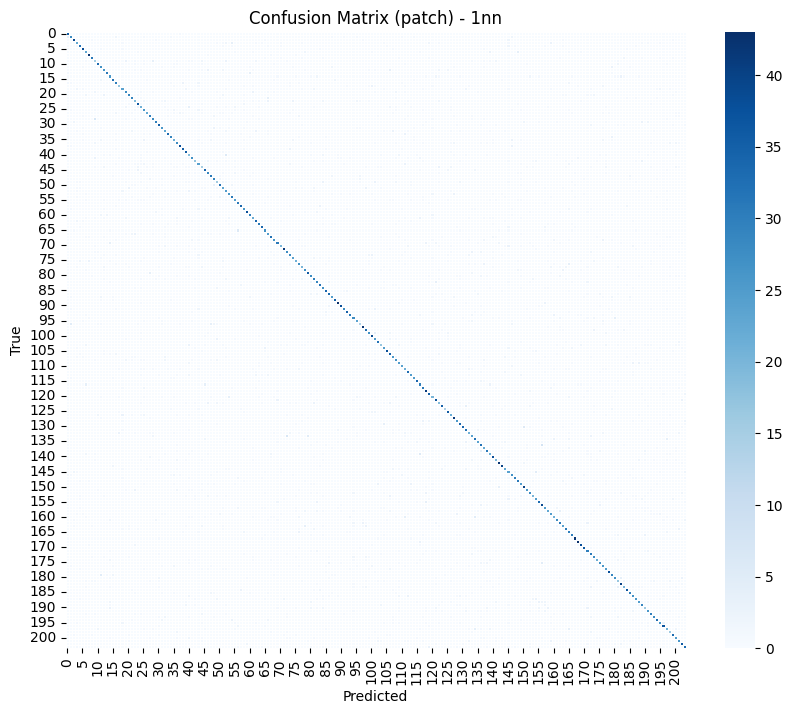

In [73]:
viz.plot_confusion(level="patch")

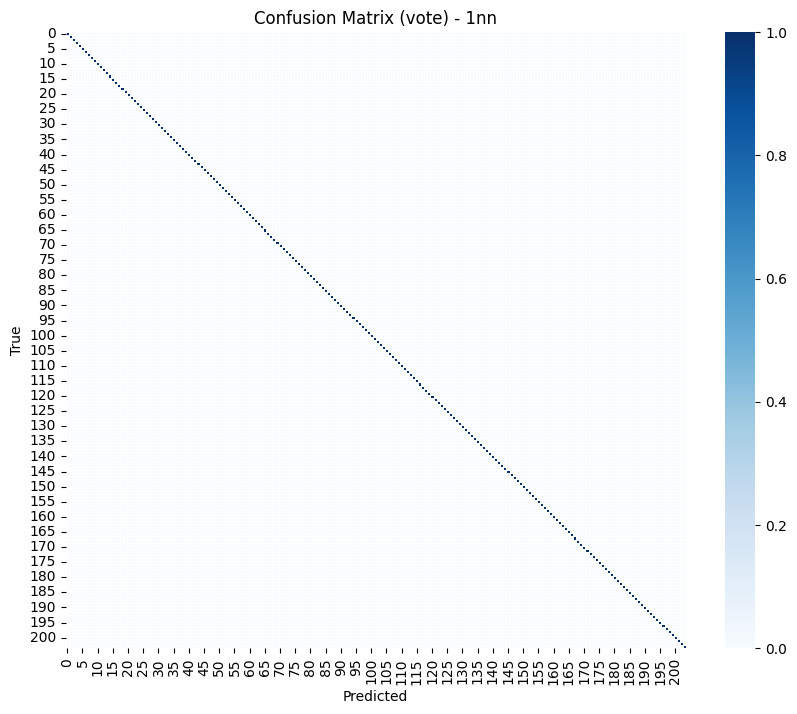

In [74]:
viz.plot_confusion(level="vote")

In [ ]:
viz.set_strategy("topk")

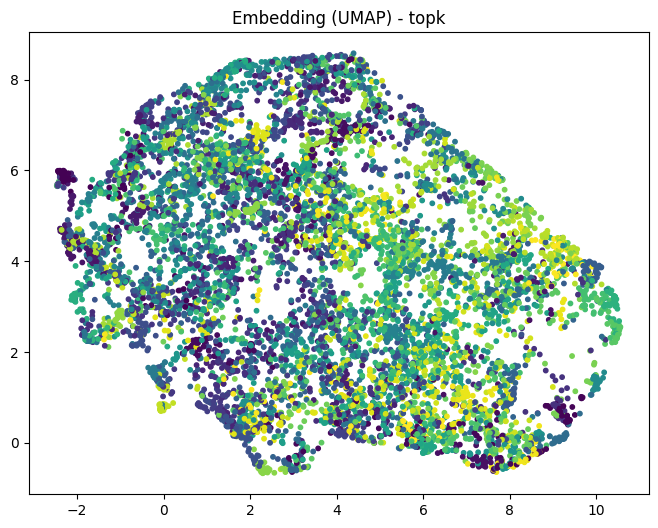

In [77]:
viz.plot_embeddings_2d()

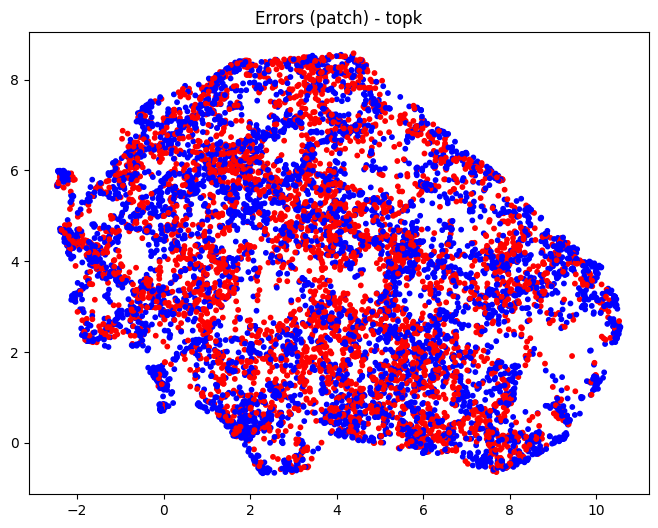

In [78]:
viz.plot_errors_2d(level="patch")

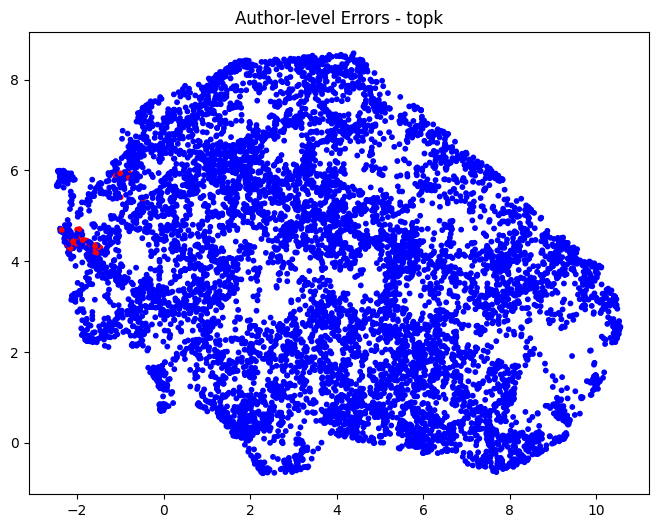

In [79]:
viz.plot_author_errors_2d()

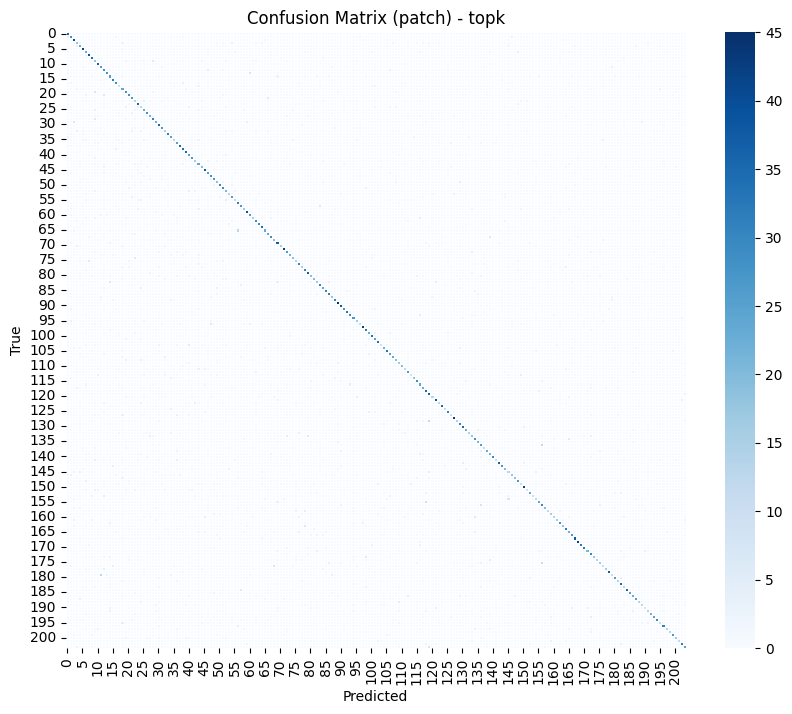

In [80]:
viz.plot_confusion("patch")

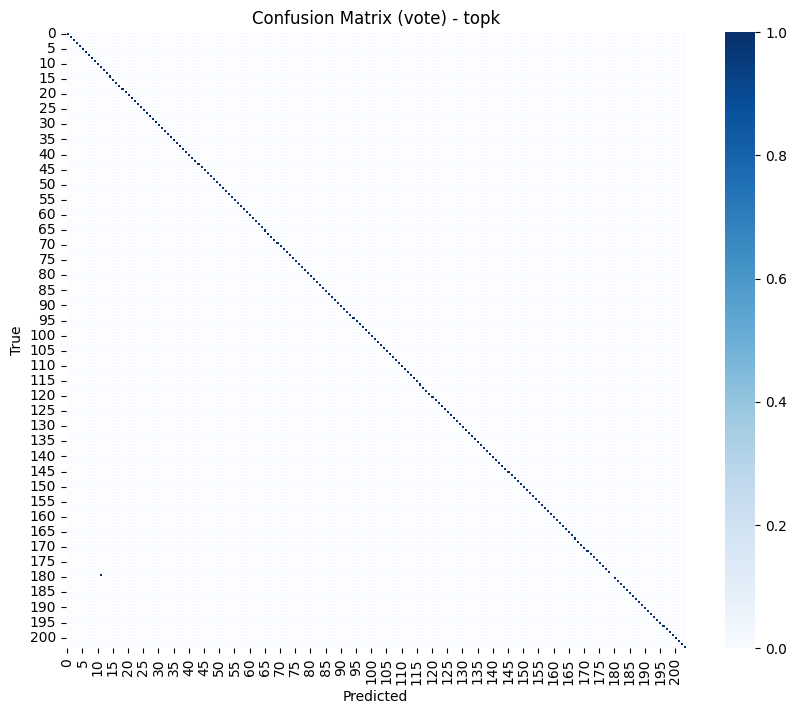

In [83]:
viz.plot_confusion("vote")

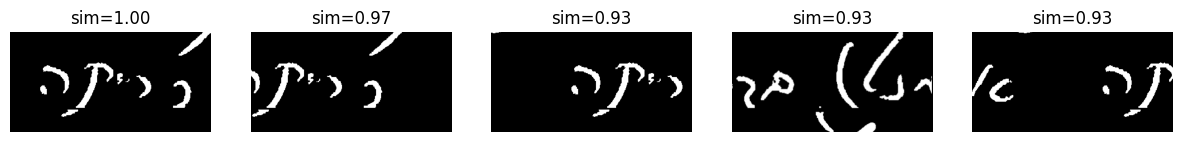

In [87]:
viz.show_nearest(df_idx=180)

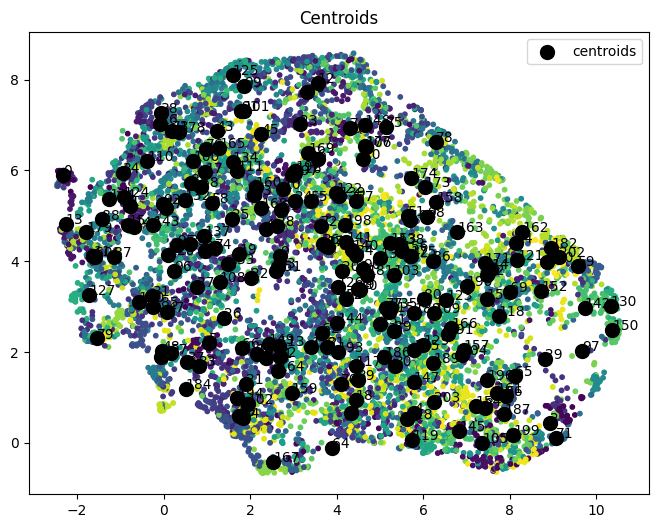

In [84]:
viz.plot_centroids()